In [1]:
import pandas as pd
import numpy as np

forecast_df = pd.read_csv(
    "../data/processed/hybrid_forecast.csv"
)

forecast_df.head()

,Actual,Prophet,LSTM,Hybrid
0,54198.37,21058.781384,23900.797,22479.789192
1,17240.61,12084.583175,28173.322,20128.952588
2,33393.29,23969.076717,26444.152,25206.614358
3,19808.40,27247.402073,27390.066,27318.734037
4,20277.05,25271.675084,26231.467,25751.571042


In [2]:
lead_time = 7

forecast_df["Forecast_Demand"] = forecast_df["Hybrid"]

forecast_df["Safety_Stock"] = (
    forecast_df["Forecast_Demand"] * 0.20
)

forecast_df["Reorder_Point"] = (
    forecast_df["Forecast_Demand"] * lead_time
) + forecast_df["Safety_Stock"]

forecast_df.head()

,Actual,Prophet,LSTM,Hybrid,Forecast_Demand,Safety_Stock,Reorder_Point
0,54198.37,21058.781384,23900.797,22479.789192,22479.789192,4495.957838,161854.482181
1,17240.61,12084.583175,28173.322,20128.952588,20128.952588,4025.790518,144928.458631
2,33393.29,23969.076717,26444.152,25206.614358,25206.614358,5041.322872,181487.623381
3,19808.40,27247.402073,27390.066,27318.734037,27318.734037,5463.746807,196694.885064
4,20277.05,25271.675084,26231.467,25751.571042,25751.571042,5150.314208,185411.311503


In [3]:
np.random.seed(42)

forecast_df["Current_Stock"] = np.random.randint(
    10000,
    300000,
    len(forecast_df)
)

forecast_df.head()

,Actual,Prophet,LSTM,Hybrid,Forecast_Demand,Safety_Stock,Reorder_Point,Current_Stock
0,54198.37,21058.781384,23900.797,22479.789192,22479.789192,4495.957838,161854.482181,131958
1,17240.61,12084.583175,28173.322,20128.952588,20128.952588,4025.790518,144928.458631,156867
2,33393.29,23969.076717,26444.152,25206.614358,25206.614358,5041.322872,181487.623381,141932
3,19808.40,27247.402073,27390.066,27318.734037,27318.734037,5463.746807,196694.885064,269178
4,20277.05,25271.675084,26231.467,25751.571042,25751.571042,5150.314208,185411.311503,129879


In [4]:
forecast_df["Inventory_Status"] = np.where(
    forecast_df["Current_Stock"]
    < forecast_df["Reorder_Point"],
    "Reorder Required",
    "Stock Sufficient"
)

forecast_df[
    [
        "Forecast_Demand",
        "Current_Stock",
        "Reorder_Point",
        "Inventory_Status"
    ]
].head()

,Forecast_Demand,Current_Stock,Reorder_Point,Inventory_Status
0,22479.789192,131958,161854.482181,Reorder Required
1,20128.952588,156867,144928.458631,Stock Sufficient
2,25206.614358,141932,181487.623381,Reorder Required
3,27318.734037,269178,196694.885064,Stock Sufficient
4,25751.571042,129879,185411.311503,Reorder Required


In [5]:
forecast_df["Inventory_Status"].value_counts()

Inventory_Status
Reorder Required    89
Stock Sufficient    26
Name: count, dtype: int64

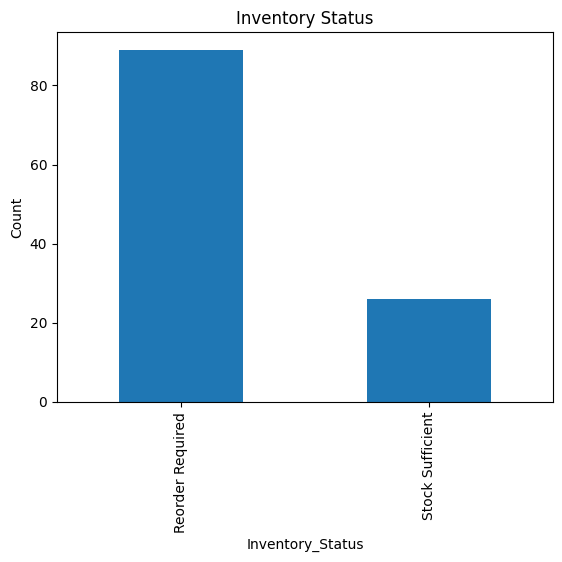

In [6]:
import matplotlib.pyplot as plt

forecast_df["Inventory_Status"].value_counts().plot(
    kind="bar"
)

plt.title("Inventory Status")
plt.ylabel("Count")

plt.savefig(
    "../screenshots/inventory_status.png"
)

plt.show()

In [7]:
forecast_df.to_csv(
    "../data/processed/inventory_optimization.csv",
    index=False
)

print("Inventory optimization saved successfully!")

Inventory optimization saved successfully!
